# paramhist
Plot histogram of image parameters for gamma ray showers and hadronic showers with the goal of reproducing Fig 7 in Fegan 1997 
https://iopscience.iop.org/article/10.1088/0954-3899/23/9/004/pdf

Author: Nik Korzoun

# Imports

In [1]:
# imports
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

# for BDT
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

import seaborn as sns

# Read Data
1 corresponds to gamma-rays and 2 corresponds to cosmic-rays

e.g. df1 is the dataframe with gamma-ray data and df2 is the dataframe with cosmic-ray data

## Data files
These data are not included in the repo. You must obtain/generate some sims.

In [ ]:
df1 = pd.read_csv("/home/nkorzoun/research/PANOSETI/High-Energy-Analysis-Pipeline.worktrees/panodisplay-updates/test_data/palomar_sim_gamma/data/_merged.csv")
df2 = pd.read_csv("/home/nkorzoun/research/PANOSETI/High-Energy-Analysis-Pipeline.worktrees/panodisplay-updates/test_data/palomar_sim_proton/data/_merged.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'test_data/palomar_sim_gamma/data/_merged.csv'

## Cleaning data

In [ ]:
# remove nans
array1=df1.dropna(subset=["Length", "Width","Miss","Distance","Azwidth","Alpha"])
array1=array1[array1["Width"]>0]
#array1.head()

array2=df2.dropna(subset=["Length", "Width","Miss","Distance","Azwidth","Alpha"])
array2=array2[array2["Width"]>0]
#array2.head()

In [ ]:
array1.describe()

,Event,Telescope,MeanX,StdX,MeanY,StdY,Phi,Size,Npix,Length,...,Az,Ze,Xcore,Ycore,stdP,TrueAz,TrueZe,TrueXcore,TrueYcore,TrueEnergy
count,147616.000000,147616.000000,147616.000000,1.476160e+05,147616.000000,1.476160e+05,147616.000000,147616.000000,147616.000000,147616.000000,...,89343.000000,89343.000000,8.934300e+04,8.934300e+04,8.934300e+04,147616.0,147616.0,147616.000000,147616.000000,147616.000000
mean,250942.995055,3.990130,0.001517,3.270285e-01,0.000214,3.215664e-01,179.749796,2758.794255,18.508312,0.415967,...,180.980054,20.050341,-7.531163e+01,-1.224427e+02,8.536740e+04,0.0,20.0,4.924602,-49.187411,39085.311587
std,144205.282127,1.998907,0.898699,9.296872e-02,0.876945,8.673437e-02,137.698065,5286.995871,9.896817,0.082179,...,179.317900,1.534517,7.045930e+03,8.750790e+03,1.284770e+07,0.0,0.0,190.561277,213.614464,54247.026567
min,7.000000,1.000000,-2.459630,7.450580e-09,-2.321370,1.862650e-09,0.000000,86.805600,2.000000,0.112568,...,0.000042,2.978550,-1.030660e+06,-7.479300e+05,0.000000e+00,0.0,20.0,-514.059000,-698.942000,10000.100000
25%,126392.750000,2.000000,-0.756680,2.490487e-01,-0.755547,2.497407e-01,43.030125,1047.055000,13.000000,0.359013,...,0.249664,19.914400,-1.299450e+02,-2.039135e+02,4.005940e-10,0.0,20.0,-133.034000,-200.021500,13482.900000
50%,251843.000000,4.000000,0.000366,3.194110e-01,0.009974,3.166830e-01,270.265500,1528.140000,16.000000,0.414867,...,346.261000,19.998600,-3.978150e+01,-6.004690e+01,1.578690e-01,0.0,20.0,-21.485300,-31.135350,20252.300000
75%,375708.500000,6.000000,0.759844,3.956780e-01,0.754165,3.858072e-01,314.175250,2596.197500,21.000000,0.469994,...,359.751000,20.083300,6.466230e+01,4.421010e+01,1.659675e+02,0.0,20.0,117.483750,113.003000,38888.300000
max,499979.000000,7.000000,2.461180,1.273620e+00,2.257950,1.132290e+00,359.999000,291830.000000,235.000000,1.631470,...,360.000000,105.803000,3.194880e+05,1.403800e+06,2.595740e+09,0.0,20.0,644.044000,510.609000,498575.000000


# Cuts

## Max Distance

In [ ]:
# create max distance parameter
max1 = array1.groupby(['Event'])['Distance'].transform('max') == array1['Distance']
max_distance1= array1.loc[max1, ['Event', 'Distance']]
array1['MaxDistance']=max_distance1.Distance
max2 = array2.groupby(['Event'])['Distance'].transform('max') == array2['Distance']
max_distance2= array2.loc[max2, ['Event', 'Distance']]
array2['MaxDistance']=max_distance2.Distance

## Apply Cuts

In [ ]:
# # cut by number of telescopes
# minTel=1
# array1 = array1.groupby('Event', group_keys=False).filter(lambda x: len(x) > (minTel-1))
# array2 = array2.groupby('Event', group_keys=False).filter(lambda x: len(x) > (minTel-1))

In [ ]:
array1 = array1[array1.Npix>2]
array2 = array2[array2.Npix>2]

# Image Parameter Distributions

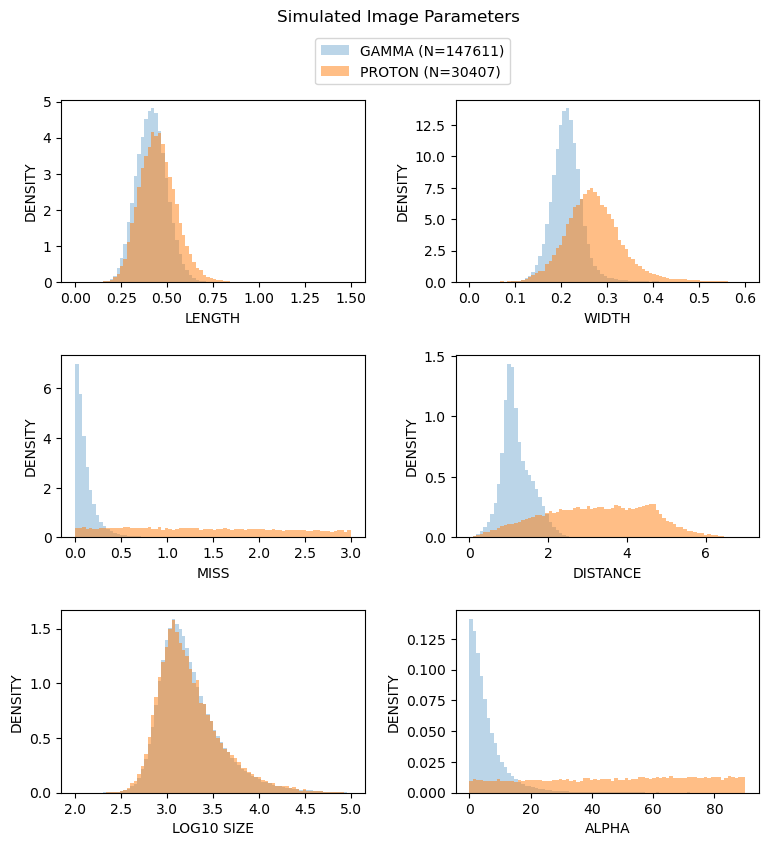

In [ ]:
fig, axs = plt.subplots(3,2, figsize=(9,9))

fig.suptitle('Simulated Image Parameters')

# select subset of showers which are nearby
# array1 = array1[np.hypot(array1["TrueXcore"].values,array1["TrueYcore"].values) < 200]
# array2 = array2[np.hypot(array2["TrueXcore"].values,array2["TrueYcore"].values) < 200]

# cut showers by distance
# array1 = array1[array1["Distance"].values < 2]
# array2 = array2[array2["Distance"].values < 2]

# cut showers by alpha
# array1 = array1[array1["Alpha"].values > 10]
# array2 = array2[array2["Alpha"].values > 10]

# cut showers by size
# array1 = array1[array1["Size"].values > 10**3]
# array2 = array2[array2["Size"].values > 10**3]

axs[0,0].hist(array1.Length, alpha=0.3, bins=80, range=(0,1.5), label='GAMMA (N={:.0f})'.format(len(array1)),density=True)
axs[0,0].hist(array2.Length, alpha=0.5, bins=80, range=(0,1.5), label='PROTON (N={:.0f})'.format(len(array2)),density=True)
axs[0,0].set(xlabel='LENGTH')
axs[0,1].hist(array1.Width, alpha=0.3, bins=80, range=(0,0.6),density=True)
axs[0,1].hist(array2.Width, alpha=0.5, bins=80, range=(0,0.6),density=True)
axs[0,1].set(xlabel='WIDTH')
axs[1,0].hist(array1.loc[:,"Miss"], alpha=0.3, bins=80, range=(0,3),density=True)
axs[1,0].hist(array2.loc[:,"Miss"], alpha=0.5, bins=80, range=(0,3),density=True)
axs[1,0].set(xlabel='MISS')
axs[1,1].hist(array1.loc[:,"Distance"], alpha=0.3, bins=80, range=(0,7),density=True)
axs[1,1].hist(array2.loc[:,"Distance"], alpha=0.5, bins=80, range=(0,7),density=True)
axs[1,1].set(xlabel='DISTANCE')
# axs[2,0].hist(array1.loc[:,"Azwidth"], alpha=0.3, bins=80, range=(0,1),density=True)
# axs[2,0].hist(array2.loc[:,"Azwidth"], alpha=0.5, bins=80, range=(0,1),density=True)
# axs[2,0].set(xlabel='AZWIDTH')
# axs[2,0].hist(array1.loc[:,"Size"], alpha=0.3, bins=80, range=(0,1e3),density=True)
# axs[2,0].hist(array2.loc[:,"Size"], alpha=0.5, bins=80, range=(0,1e3),density=True)
axs[2,0].set(xlabel='Size')
axs[2,0].hist(np.log10(array1.loc[:,"Size"]), alpha=0.3, bins=80, range=(2,5),density=True)
axs[2,0].hist(np.log10(array2.loc[:,"Size"]), alpha=0.5, bins=80, range=(2,5),density=True)
axs[2,0].set(xlabel='LOG10 SIZE')
axs[2,1].hist(array1.loc[:,"Alpha"], alpha=0.3, bins=80, range=(0,90),density=True)
axs[2,1].hist(array2.loc[:,"Alpha"], alpha=0.5, bins=80, range=(0,90),density=True)
axs[2,1].set(xlabel='ALPHA')

for ax in axs.flat:
    # ax.set(ylabel='POPULATION (normalized)')
    ax.set(ylabel='DENSITY')

plt.subplots_adjust(hspace=0.4,wspace=0.3)
fig.legend(loc=(0.41,0.9))

# plt.savefig('/home/nkorzoun/Downloads/sim_params.png',dpi=300)

In [ ]:
array1.head()

,Event,Telescope,MeanX,StdX,MeanY,StdY,Phi,Size,Npix,Length,...,Ze,Xcore,Ycore,stdP,TrueAz,TrueZe,TrueXcore,TrueYcore,TrueEnergy,MaxDistance
10,99002,4,0.749127,0.525643,0.142622,0.253668,19.5994,888.752,14,0.554144,...,NaN,NaN,NaN,NaN,0,20,393.236,169.247,11679.0,0.762582
63,99010,1,0.587481,0.251048,1.411350,0.364887,61.8948,746.606,11,0.401401,...,20.078,-41.0645,-230.732,351.999,0,20,-56.130,-201.360,45316.1,NaN
64,99010,2,-0.479375,0.460027,0.085297,0.283192,354.4680,7319.460,37,0.461378,...,20.078,-41.0645,-230.732,351.999,0,20,-56.130,-201.360,45316.1,NaN
65,99010,3,1.274320,0.463330,0.479827,0.236157,16.3349,2121.370,18,0.479173,...,20.078,-41.0645,-230.732,351.999,0,20,-56.130,-201.360,45316.1,NaN
67,99010,5,0.327436,0.235182,-1.583360,0.435442,280.7620,1328.550,18,0.441184,...,20.078,-41.0645,-230.732,351.999,0,20,-56.130,-201.360,45316.1,1.616860


In [ ]:
def get_telescope_X(n):
    if(n==3):
        return 126.65
    elif(n==1):
        return -101.35
    else:
        return -25.29

def get_telescope_Y(n):
    if(n==3):
        return -42.32
    elif(n==1):
        return -42.32
    else:
        return 84.64

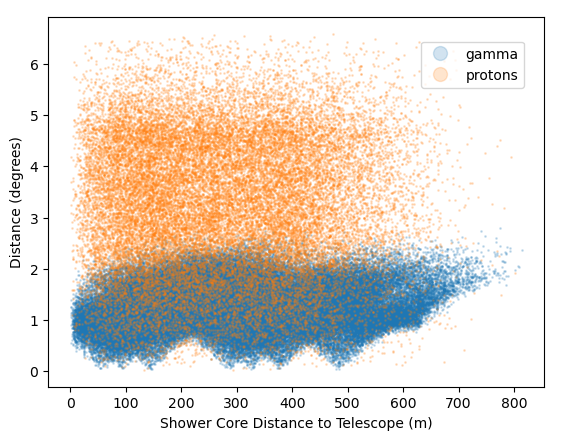

In [ ]:
array1["TelX"] = array1["Telescope"].apply(get_telescope_X)
array1["TelY"] = array1["Telescope"].apply(get_telescope_Y)
array2["TelX"] = array2["Telescope"].apply(get_telescope_X)
array2["TelY"] = array2["Telescope"].apply(get_telescope_Y)

r1=np.hypot(array1["TrueXcore"]-array1["TelX"],array1["TrueYcore"]-array1["TelY"])
dist1=array1["Distance"]
r2=np.hypot(array2["TrueXcore"]-array2["TelX"],array2["TrueYcore"]-array2["TelY"])
dist2=array2["Distance"]

fig,axs = plt.subplots()
plt.xlabel('Shower Core Distance to Telescope (m)')
plt.ylabel('Distance (degrees)')
axs.plot(r1,dist1,linestyle='None',alpha=0.2,marker='o',markersize=1,label='gamma')
axs.plot(r2,dist2,linestyle='None',alpha=0.2,marker='o',markersize=1,label='protons')

fig.legend(loc=(0.75,0.8),markerscale=10)

In [ ]:
# fig,axs = plt.subplots()
# plt.xlabel('Log10(Size)')
# plt.ylabel('Max Distance')
# axs.plot(np.log10(array1.Size),array1.MaxDistance,linestyle='None',alpha=0.2,marker='o',markersize=1,label='gamma')
# axs.plot(np.log10(array2.Size),array2.MaxDistance,linestyle='None',alpha=0.2,marker='o',markersize=1,label='protons')

# # plt.ylim(1,2.4)
# # plt.xlim(2.4,4.5)
# fig.legend(loc=(0.75,0.8),markerscale=10)

In [ ]:
# sns.regplot(x=np.log10(array1.Size),y=array1.MaxDistance, x_bins=12,x_estimator=np.mean)

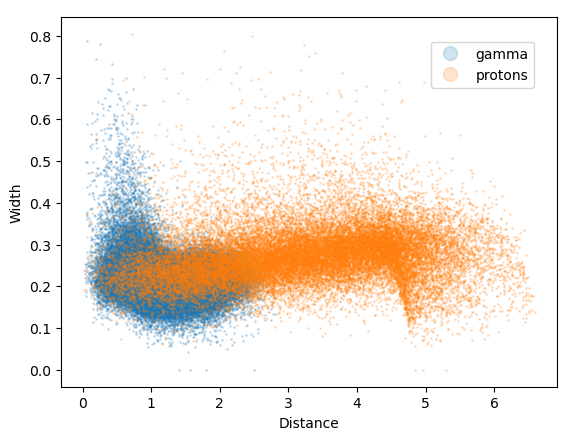

In [ ]:
width1=array1["Width"]
dist1=array1["Distance"]
width2=array2["Width"]
dist2=array2["Distance"]

fig,axs = plt.subplots()
plt.xlabel('Distance')
plt.ylabel('Width')
axs.plot(dist1,width1,linestyle='None',alpha=0.2,marker='o',markersize=1,label='gamma')
axs.plot(dist2,width2,linestyle='None',alpha=0.2,marker='o',markersize=1,label='protons')

fig.legend(loc=(0.75,0.8),markerscale=10)

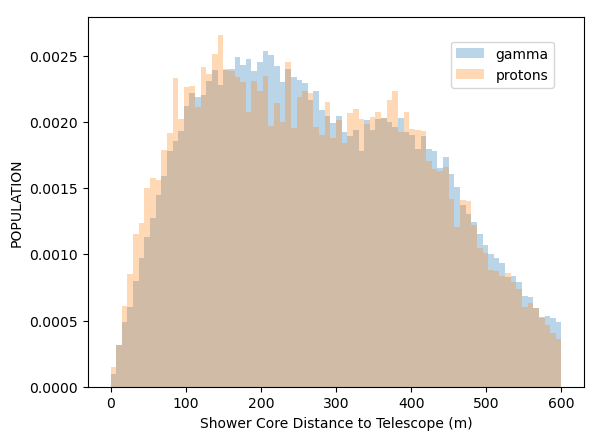

In [ ]:
fig,axs = plt.subplots()
plt.xlabel('Shower Core Distance to Telescope (m)')
plt.ylabel('POPULATION')
axs.hist(r1,linestyle='None', alpha=0.3, bins=80, range=(0,600),density=True, label='gamma')
axs.hist(r2,linestyle='None', alpha=0.3, bins=80, range=(0,600),density=True,label='protons')

fig.legend(loc=(0.75,0.8),markerscale=10)

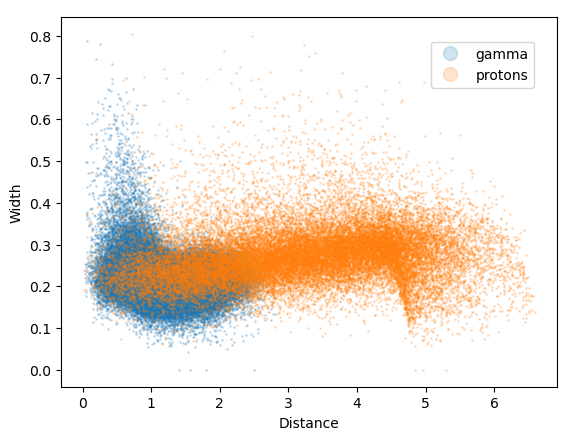

In [ ]:
width1=array1["Width"]
dist1=array1["Distance"]
width2=array2["Width"]
dist2=array2["Distance"]

fig,axs = plt.subplots()
plt.xlabel('Distance')
plt.ylabel('Width')
axs.plot(dist1,width1,linestyle='None',alpha=0.2,marker='o',markersize=1,label='gamma')
axs.plot(dist2,width2,linestyle='None',alpha=0.2,marker='o',markersize=1,label='protons')

fig.legend(loc=(0.75,0.8),markerscale=10)

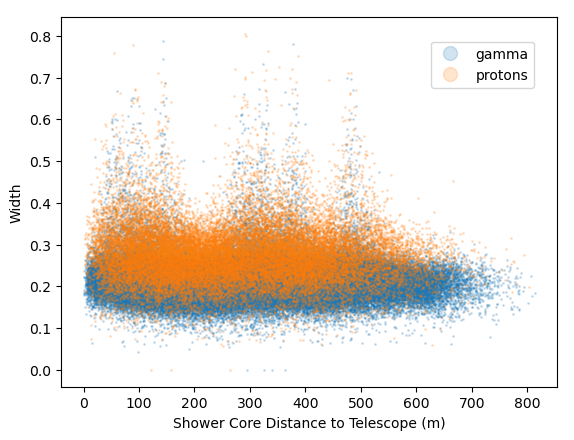

In [ ]:
fig,axs = plt.subplots()
plt.xlabel('Shower Core Distance to Telescope (m)')
plt.ylabel('Width')
axs.plot(r1,width1,linestyle='None',alpha=0.2,marker='o',markersize=1,label='gamma')
axs.plot(r2,width2,linestyle='None',alpha=0.2,marker='o',markersize=1,label='protons')

fig.legend(loc=(0.75,0.8),markerscale=10)

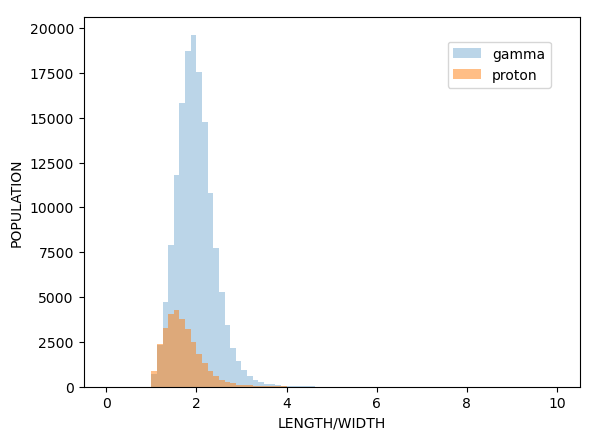

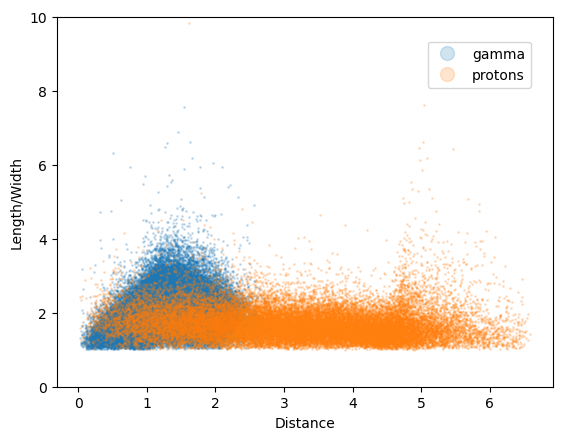

In [ ]:
length1=array1["Length"]
length2=array2["Length"]

fig, axs = plt.subplots()
plt.xlabel('LENGTH/WIDTH')
plt.ylabel('POPULATION')
axs.hist(array1.loc[:,"Length"]/array1.loc[:,"Width"], alpha=0.3, bins=80, range=(0,10), label='gamma')
axs.hist(array2.loc[:,"Length"]/array2.loc[:,"Width"], alpha=0.5, bins=80, range=(0,10), label='proton')
fig.legend(loc=(0.75,0.8))

fig,axs = plt.subplots()
plt.xlabel('Distance')
plt.ylabel('Length/Width')
plt.ylim(0,10)
axs.plot(dist1,length1/width1,linestyle='None',alpha=0.2,marker='o',markersize=1,label='gamma')
axs.plot(dist2,length2/width2,linestyle='None',alpha=0.2,marker='o',markersize=1,label='protons')
fig.legend(loc=(0.75,0.8),markerscale=10)

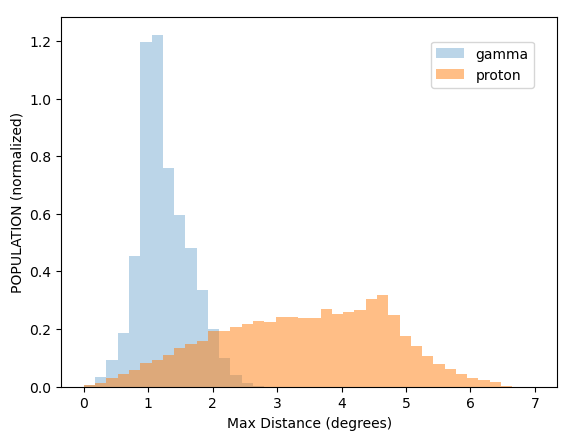

In [ ]:
fig, axs = plt.subplots()
plt.xlabel('Max Distance (degrees)')
plt.ylabel('POPULATION (normalized)')

max1 = array1.groupby(['Event'])['Distance'].transform('max') == array1['Distance']
max_distance1= array1.loc[max1, ['Event', 'Distance']]
max2 = array2.groupby(['Event'])['Distance'].transform('max') == array2['Distance']
max_distance2= array2.loc[max2, ['Event', 'Distance']]

axs.hist(max_distance1.Distance, alpha=0.3, bins=40, range=(0,7), label='gamma',density=True)
axs.hist(max_distance2.Distance, alpha=0.5, bins=40, range=(0,7), label='proton',density=True)
fig.legend(loc=(0.75,0.8))

In [ ]:
max_distance2.head(20)

,Event,Distance
72,99011,2.80360
170,99025,2.49499
226,99033,4.86922
526,99076,3.77506
874,99125,2.69844
878,99126,2.19547
1196,99171,4.42080
1400,99201,5.33612
1425,99204,4.97962
1557,99223,2.26068


# Testing Mean-Scaled Parameters

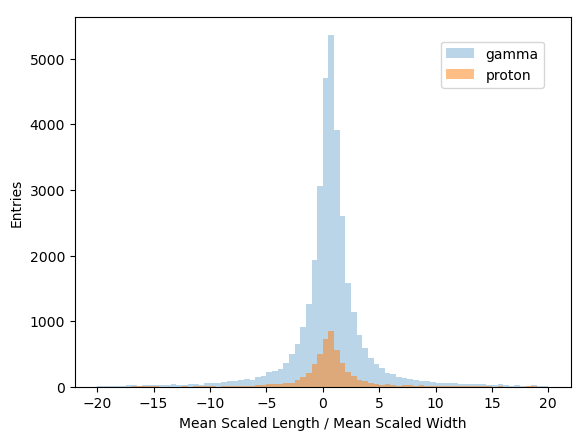

In [ ]:
mean_w1=np.mean(array1["Width"])
std_w1=np.std(array1["Width"])
mean_w2=np.mean(array2["Width"])
std_w2=np.std(array2["Width"])

mean_l1=np.mean(array1["Length"])
std_l1=np.std(array1["Length"])
mean_l2=np.mean(array2["Length"])
std_l2=np.std(array2["Length"])

data1 = array1.groupby('Event', group_keys=False).filter(lambda x: len(x) > 1) # require more than 1 telescope
data2 = array2.groupby('Event', group_keys=False).filter(lambda x: len(x) > 1) # require more than 1 telescope

mscw1=pd.DataFrame(data=None, columns=["Event","MSCW"])
for i in data1["Event"].drop_duplicates():
    event = data1[data1["Event"]==i]
    mscw1.loc[len(mscw1)] = [i,np.sum( (event["Width"]-mean_w1)/std_w1 ) / len(event)]

mscw2=pd.DataFrame(data=None, columns=["Event","MSCW"])
for i in data2["Event"].drop_duplicates():
    event = data2[data2["Event"]==i]
    mscw2.loc[len(mscw2)] = [i,np.sum( (event["Width"]-mean_w2)/std_w2 ) / len(event)]

mscl1=pd.DataFrame(data=None, columns=["Event","MSCL"])
for i in data1["Event"].drop_duplicates():
    event = data1[data1["Event"]==i]
    mscl1.loc[len(mscl1)] = [i,np.sum( (event["Length"]-mean_l1)/std_l1 ) / len(event)]

mscl2=pd.DataFrame(data=None, columns=["Event","MSCL"])
for i in data2["Event"].drop_duplicates():
    event = data2[data2["Event"]==i]
    mscl2.loc[len(mscl2)] = [i,np.sum( (event["Length"]-mean_l2)/std_l2 ) / len(event)]

fig = plt.figure();
plt.xlabel('Mean Scaled Length / Mean Scaled Width')
plt.ylabel('Entries')
plt.hist(mscl1["MSCL"]/mscw1["MSCW"], bins=80, range=(-20,20), alpha=0.3, label='gamma');
plt.hist(mscl2["MSCL"]/mscw2["MSCW"], bins=80, range=(-20,20), alpha=0.5, label='proton');
fig.legend(loc=(0.75,0.8))


In [ ]:
# do not calculate mean from bins outside the plotting range (some are erroneously large, >1e7)
gamma_lw=mscl1['MSCL']/mscw1['MSCW']
proton_lw=mscl2['MSCL']/mscw2['MSCW']

gamma_lw=gamma_lw[gamma_lw>-20]
gamma_lw=gamma_lw[gamma_lw<20]
proton_lw=proton_lw[proton_lw>-20]
proton_lw=proton_lw[proton_lw<20]

print("Gamma mean: {:.5f} degrees, N={}".format(gamma_lw.mean(),len(gamma_lw)))
print("Proton mean: {:.5f} degrees, N={}".format(proton_lw.mean(),len(proton_lw)))

Gamma mean: 0.66210 degrees, N=34542
Proton mean: 0.55968 degrees, N=5249


# BDT
Based on https://arxiv.org/pdf/1701.06928.pdf
 - 200 trees
 - learning rate 1
 - max depth 50
 - Gini separation, best split

 I have not included
 - Cost complexity pruning 
    - at a glance, it performs worse, and I don't know what complexity is used in the paper

## set up classifier

In [ ]:
tree = DecisionTreeClassifier(criterion="gini", splitter="best", max_depth=50, random_state=0)
classifier = AdaBoostClassifier(estimator=tree, n_estimators=200, learning_rate=1.0, random_state=0)

## create training set

In [ ]:
data1 = array1[["Size","Length","Width","Distance"]]
data2 = array2[["Size","Length","Width","Distance"]]

data1 = data1.dropna()
data2 = data2.dropna()

# add length/width as a feature
data1["Length/Width"] = data1["Length"]/data1["Width"]
data2["Length/Width"] = data2["Length"]/data2["Width"]

# classify gamma as 1 and proton as 2
data1["Classification"] = 1
data2["Classification"] = 2

# combine data
X = pd.concat([data1,data2])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X.iloc[:,:-1],X[["Classification"]], test_size=0.33, random_state=0)

In [ ]:
X_train.head()

,Size,Length,Width,Distance,Length/Width
3091410,3640.29,0.433855,0.199333,1.146240,2.176534
1037570,1068.47,0.492195,0.180886,1.341710,2.721023
1871775,1626.53,0.327525,0.267706,0.629403,1.223450
2940525,1561.50,0.498066,0.242575,0.933821,2.053245
2153723,1913.96,0.378302,0.222726,1.576780,1.698508


In [ ]:
y_train.head()

,Classification
3091410,1
1037570,1
1871775,1
2940525,2
2153723,1


## train BDT

In [ ]:
classifier.fit(X_train, y_train.values.ravel())
classifier.score(X_test, y_test.values.ravel())

/home/nkorzoun/.conda/envs/panoseti/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


0.9302761039049467

## results

### feature importance

In [ ]:
features=np.array(list(zip(X_train.columns,classifier.feature_importances_)))
features=features[features[:, 1].argsort()][::-1]

print("Feature:\tFrequency:")
for f in features:
    print("{:<16}{:.2f} ".format(f[0],float(f[1])))

Feature:	Frequency:
Distance        0.76 
Width           0.08 
Size            0.06 
Length          0.05 
Length/Width    0.04 


### confusion matrix

<Figure size 6400x4800 with 0 Axes>

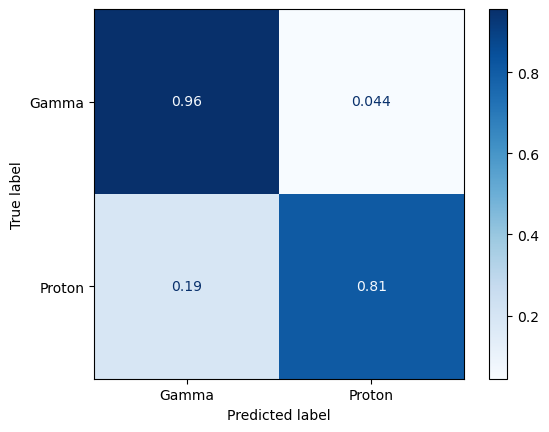

<Figure size 6400x4800 with 0 Axes>

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(
    classifier,
    X_test,
    y_test,
    display_labels=["Gamma","Proton"],
    cmap=plt.cm.Blues,
    normalize="true"
)
# disp.ax_.set_title("Confusion Matrix")

plt.figure(dpi=1000)

### Identify false labelings

In [ ]:
correct = X_test[y_test.values.ravel()==classifier.predict(X_test)]
correct["Classification"] = y_test[y_test["Classification"].values.ravel()==classifier.predict(X_test)]
incorrect = X_test[y_test.values.ravel()!=classifier.predict(X_test)]
incorrect["Classification"] = y_test[y_test["Classification"].values.ravel()!=classifier.predict(X_test)]

/tmp/ipykernel_92423/1394113726.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  correct["Classification"] = y_test[y_test["Classification"].values.ravel()==classifier.predict(X_test)]
/tmp/ipykernel_92423/1394113726.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  incorrect["Classification"] = y_test[y_test["Classification"].values.ravel()!=classifier.predict(X_test)]


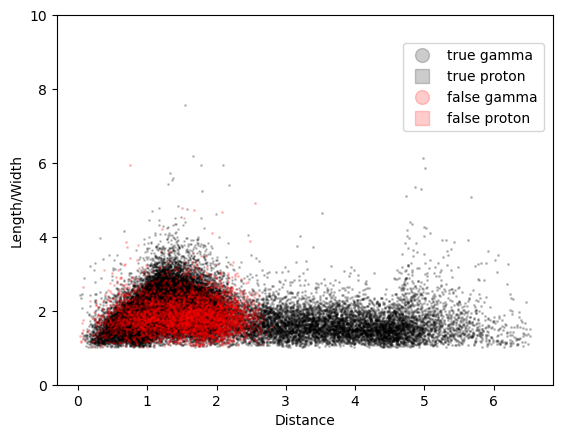

In [ ]:
fig,axs = plt.subplots()
plt.xlabel('Distance')
plt.ylabel('Length/Width')
plt.ylim(0,10)
axs.plot(correct[correct["Classification"]==1]["Distance"],correct[correct["Classification"]==1]["Length/Width"],c="black",alpha=0.2,linestyle='None',marker='o',markersize=1,label='true gamma')
axs.plot(correct[correct["Classification"]==2]["Distance"],correct[correct["Classification"]==2]["Length/Width"],c="black",alpha=0.2,linestyle='None',marker='s',markersize=1,label='true proton')
axs.plot(incorrect[incorrect["Classification"]!=1]["Distance"],incorrect[incorrect["Classification"]!=1]["Length/Width"],c="red",alpha=0.2,linestyle='None',marker='o',markersize=1,label='false gamma')
axs.plot(incorrect[incorrect["Classification"]!=2]["Distance"],incorrect[incorrect["Classification"]!=2]["Length/Width"],c="red",alpha=0.2,linestyle='None',marker='s',markersize=1,label='false proton')
fig.legend(loc=(0.7,0.7),markerscale=10)

# Angular Resolution

In [ ]:
def plotPSF(dataframe=df1, title="Photon Events", angle_range=(0,10), core_range=(0,200),threshold=10000):

    # energy threshold
    dataframe=dataframe[dataframe["TrueEnergy"]>threshold]

    data1 = dataframe.dropna(subset=["Az","Ze"]).drop_duplicates(subset="Event")
    c1 = SkyCoord(az=data1["Az"].values*u.deg, alt=(90-data1["Ze"].values)*u.deg, frame='altaz')
    c2 = SkyCoord(az=data1["TrueAz"].values*u.deg, alt=(90-data1["TrueZe"].values)*u.deg,frame='altaz')
    angle1=pd.DataFrame(c1.separation(c2).deg)
    core1 = pd.DataFrame(np.abs(np.hypot(data1["Xcore"].values,data1["Ycore"].values)-np.hypot(data1["TrueXcore"].values,data1["TrueYcore"].values)))

    data2 = dataframe.dropna(subset=["Az","Ze"]).dropna(subset="Alpha")
    data2 = data2.groupby('Event', group_keys=False).filter(lambda x: len(x) > 2).drop_duplicates(subset="Event") #require more than 2 telescopes
    c1 = SkyCoord(az=data2["Az"].values*u.deg, alt=(90-data2["Ze"].values)*u.deg, frame='altaz')
    c2 = SkyCoord(az=data2["TrueAz"].values*u.deg, alt=(90-data2["TrueZe"].values)*u.deg,frame='altaz')
    angle2=pd.DataFrame(c1.separation(c2).deg)
    core2 = pd.DataFrame(np.abs(np.hypot(data2["Xcore"].values,data2["Ycore"].values)-np.hypot(data2["TrueXcore"].values,data2["TrueYcore"].values)))

    fig, axs = plt.subplots(1,2, figsize=(10,4))
    fig.suptitle(title)

    axs[0].set_xlabel(r'Squared Angular Error [degrees$^2$]')
    axs[0].set_ylabel('Entries')
    axs[0].hist(angle1*angle1, alpha=0.3, bins = 40, range=angle_range,label = 'at least 2 telescopes' )
    axs[0].hist(angle2*angle2, alpha=0.5, bins = 40, range=angle_range,label = '3 telescopes' )

    axs[1].set_xlabel('Core Error [m]')
    axs[1].set_ylabel('Entries')
    axs[1].hist(core1, alpha=0.3, bins = 40, range=core_range,label = 'at least 2 telescopes')
    axs[1].hist(core2, alpha=0.5, bins = 40, range=core_range,label = '3 telescopes')

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels)

    return fig, angle1, core1, angle2, core2


## Photon Events

====== At least 2 Telescopes ======
Angular Error 68% value: 0.24819 degrees, N=35754
Core Reconstruction 68% value: 43.50229 m, N=35754
====== 3 Telescopes ======
Angular Error 68% value: 0.15468 degrees, N=13772
Core Reconstruction 68% value: 36.26031 m, N=13772


/tmp/ipykernel_92423/21067074.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


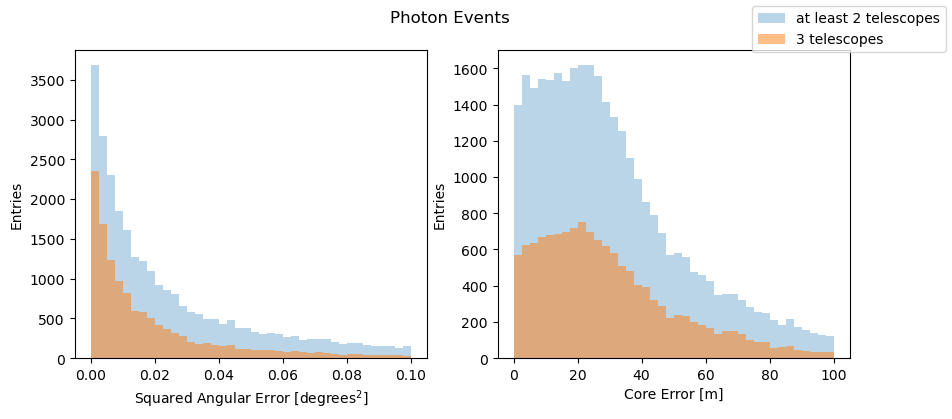

In [ ]:
fig, angle1, core1, angle2, core2 = plotPSF(df1, "Photon Events", (0,0.1),(0,100))

fig.show()

print("====== At least 2 Telescopes ======")
print("Angular Error 68% value: {:.5f} degrees, N={}".format(angle1[0].quantile(0.68), angle1[0].count()))
print("Core Reconstruction 68% value: {:.5f} m, N={}".format(core1[0].quantile(0.68),core1[0].count()))

print("====== 3 Telescopes ======")
print("Angular Error 68% value: {:.5f} degrees, N={}".format(angle2[0].quantile(0.68), angle2[0].count()))
print("Core Reconstruction 68% value: {:.5f} m, N={}".format(core2[0].quantile(0.68),core2[0].count()))

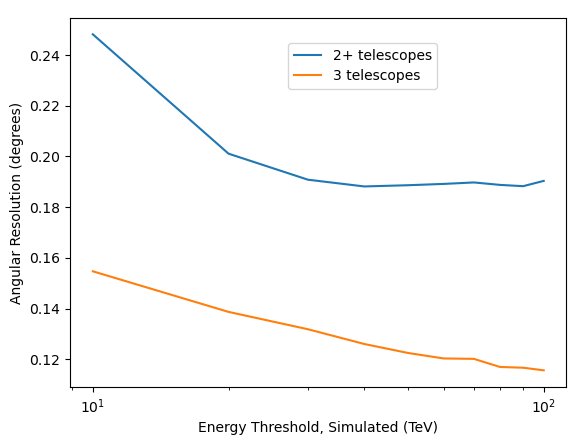

In [ ]:
# angular resolution as a function of energy
thresholds = np.linspace(10,100,10)
resolution1 = []
resolution2 = []
for e in thresholds:
    fig, angle1, core1, angle2, core2 = plotPSF(df1, "Photon Events", (0,0.1),(0,100),e*1000)
    plt.close()
    resolution1.append(angle1[0].quantile(0.68))
    resolution2.append(angle2[0].quantile(0.68))
    #print(len(angle1))


fig,axs = plt.subplots()
plt.xlabel('Energy Threshold, Simulated (TeV)')
plt.ylabel('Angular Resolution (degrees)')

axs.plot(thresholds,resolution1, label='2+ telescopes')
axs.plot(thresholds,resolution2, label='3 telescopes')
axs.set_xscale('log')

fig.legend(loc=(0.5,0.8),markerscale=10)


### Proton Events

====== At least 2 Telescopes ======
Angular Error 68% value: 3.97045 degrees, N=5449
Core Reconstruction 68% value: 54.89993 m, N=5449
====== 3 Telescopes ======
Angular Error 68% value: 3.65940 degrees, N=1722
Core Reconstruction 68% value: 42.38109 m, N=1722


/tmp/ipykernel_92423/1985813910.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


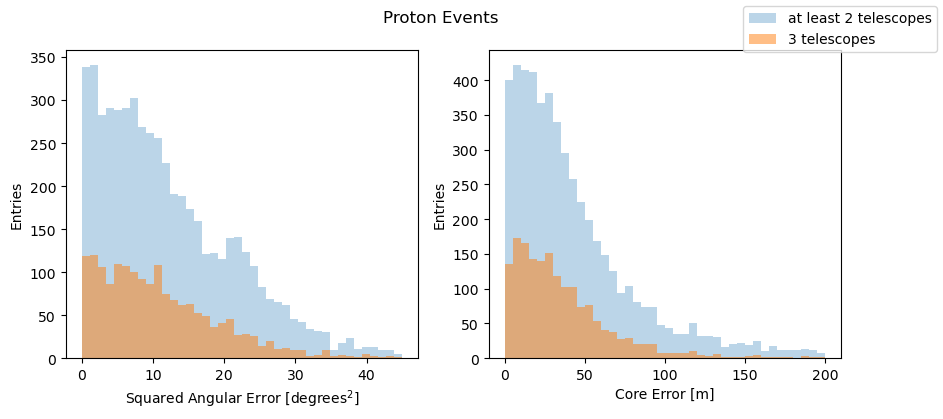

In [ ]:
fig, angle1, core1, angle2, core2 = plotPSF(df2, "Proton Events", (0,45), (0,200))

fig.show()

print("====== At least 2 Telescopes ======")
print("Angular Error 68% value: {:.5f} degrees, N={}".format(angle1[0].quantile(0.68), angle1[0].count()))
print("Core Reconstruction 68% value: {:.5f} m, N={}".format(core1[0].quantile(0.68),core1[0].count()))

print("====== 3 Telescopes ======")
print("Angular Error 68% value: {:.5f} degrees, N={}".format(angle2[0].quantile(0.68), angle2[0].count()))
print("Core Reconstruction 68% value: {:.5f} m, N={}".format(core2[0].quantile(0.68),core2[0].count()))

# Effective Area

## photon events

In [ ]:
triggeredEvents = df1.dropna(subset=["Az","Ze"]).dropna(subset="Alpha")
# require 2 telescopes
triggeredEvents = triggeredEvents.groupby('Event', group_keys=False).filter(lambda x: len(x) > 1).drop_duplicates(subset="Event")
#triggeredEvents = triggeredEvents[triggeredEvents["Alpha"]<0.23] # theta cut?
triggeredEvents.describe()

,Event,Telescope,MeanX,StdX,MeanY,StdY,Phi,Size,Npix,Length,...,Az,Ze,Xcore,Ycore,stdP,TrueAz,TrueZe,TrueXcore,TrueYcore,TrueEnergy
count,35754.000000,35754.000000,35754.000000,35754.000000,35754.000000,3.575400e+04,35754.000000,35754.000000,35754.000000,35754.000000,...,35754.000000,35754.000000,3.575400e+04,3.575400e+04,3.575400e+04,35754.0,35754.0,35754.000000,35754.000000,35754.000000
mean,251043.880573,2.153997,0.018464,0.324374,0.299201,3.237238e-01,201.151938,2838.085415,18.594591,0.415957,...,180.875625,20.064010,-8.680642e+01,-1.337002e+02,1.066077e+05,0.0,20.0,-30.077173,-52.278684,40734.079762
std,144143.337327,1.631937,0.888776,0.091874,0.854103,8.744306e-02,135.417554,5663.923696,9.971176,0.081091,...,179.213271,1.713587,7.875554e+03,9.781186e+03,1.436084e+07,0.0,0.0,136.453060,167.943332,54470.296822
min,9.000000,1.000000,-2.311030,0.000000,-2.304330,2.107340e-08,0.000000,115.913000,2.000000,0.119063,...,0.000042,2.978550,-1.030660e+06,-7.479300e+05,0.000000e+00,0.0,20.0,-447.085000,-554.207000,10000.700000
25%,126411.500000,1.000000,-0.743735,0.246622,-0.332438,2.499055e-01,54.590550,1041.665000,13.000000,0.360503,...,0.276999,19.905425,-1.354395e+02,-2.221545e+02,2.320055e-10,0.0,20.0,-129.876500,-176.162000,14223.100000
50%,252732.000000,1.000000,0.058163,0.317353,0.460155,3.198350e-01,284.155500,1548.935000,16.000000,0.415911,...,340.462000,19.998900,-3.978960e+01,-5.898050e+01,4.985005e-09,0.0,20.0,-42.494000,-35.620900,21751.500000
75%,375250.750000,2.000000,0.767597,0.392522,0.963834,3.903590e-01,319.138250,2711.785000,21.000000,0.469168,...,359.722000,20.092900,7.131960e+01,5.281065e+01,6.508905e+01,0.0,20.0,64.692575,80.070675,41653.450000
max,499979.000000,6.000000,2.461180,1.211040,2.257950,1.005660e+00,359.992000,291830.000000,235.000000,1.552270,...,360.000000,105.803000,3.194880e+05,1.403800e+06,2.595740e+09,0.0,20.0,405.683000,458.888000,497423.000000


### 2+ telescope triggered events

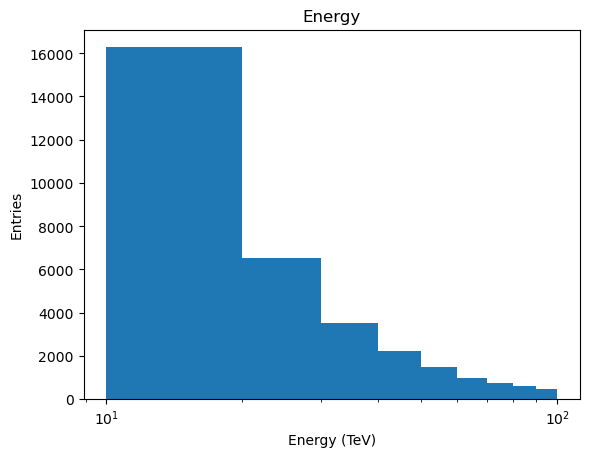

In [ ]:
fig = plt.figure();
plt.title('Energy')
plt.xlabel('Energy (TeV)')
plt.ylabel('Entries')
plt.hist(triggeredEvents["TrueEnergy"]/1000, bins=9, range=(10,100));
plt.xscale('log');



### all simulated events

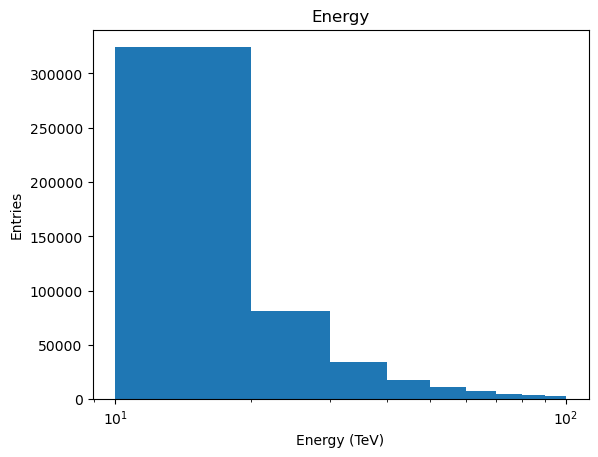

In [ ]:
fig = plt.figure();
plt.title('Energy')
plt.xlabel('Energy (TeV)')
plt.ylabel('Entries')
#plt.hist(df1[df1["Alpha"]<0.23].drop_duplicates(subset="Event")["TrueEnergy"]/1000, bins=9, range=(10,100)); # theta cut?
plt.hist(df1.drop_duplicates(subset="Event")["TrueEnergy"]/1000, bins=9, range=(10,100));
plt.xscale('log');

In [ ]:
# LHAASO data
# from https://www.science.org/doi/10.1126/sciadv.adj2778
# points digitized from https://apps.automeris.io/wpd/
km2a=[[10, 3.2e+5],
# [11, 3.7e+5],
# [11, 4.2e+5],
[12, 4.6e+5],
# [13, 5.1e+5],
# [14, 5.7e+5],
# [14, 6.1e+5],
[15, 6.4e+5],
# [16, 6.7e+5],
# [17, 7.1e+5],
[18, 7.3e+5],
# [19, 7.5e+5],
[21, 7.6e+5],
# [22, 7.9e+5],
# [23, 7.9e+5],
[25, 8.0e+5],
[42, 8.3e+5],
# [45, 8.5e+5],
# [48, 8.3e+5],
[51, 8.3e+5],
[54, 8.3e+5],
# [57, 8.4e+5],
[60, 8.3e+5],
# [63, 8.3e+5],
[82, 8.3e+5],
[87, 8.4e+5],
[91, 8.4e+5],
[1.0e+2, 8.4e+5]]

kx, ky = zip(*km2a)
ky=[n/1e+6 for n in ky]

Text(0.5, 1.0, 'Effective Area')

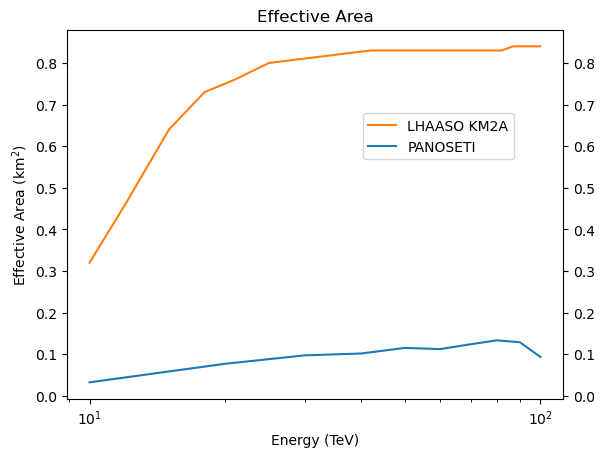

In [ ]:
# calculate effective area
triggered, binEdges = np.histogram(triggeredEvents["TrueEnergy"]/1000,bins=10)
all, _ = np.histogram(df1.drop_duplicates(subset="Event")["TrueEnergy"]/1000,bins=10)

effA = np.pi*0.4*0.4*triggered/all
effAerr = np.sqrt(triggered)*np.pi*0.4*0.4/all

fig,axs = plt.subplots()
plt.xlabel('Energy (TeV)')
plt.ylabel(r'Effective Area (km$^2$)')

#axs.plot([10,100],[1.3,1.3],label='LHAASO KM2A', color='tab:orange')
axs.plot(kx,ky,label='LHAASO KM2A', color='tab:orange')

bincenters = 0.5*(binEdges[1:]+binEdges[:-1])
#axs.errorbar(bincenters,effA,yerr=effAerr,linestyle='None',color='tab:blue')
axs.plot([10,20,30,40,50,60,70,80,90,100],effA,color='tab:blue',label='PANOSETI')
axs.set_xscale('log')
#axs.set_yscale('log')
plt.tick_params(labelright=True,right=True,which='both')
#plt.yticks([0.01,0.1,1])
fig.legend(loc=(0.6,0.65),markerscale=10)
plt.title("Effective Area")
